## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import string
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv
import pickle
import re

In [2]:
object_name = 'Konstytucja_prediction' #Konstytucja_indicators / Konstytucja_prediction

fifteen_or_not = 'all_15' 
collapse = False

if fifteen_or_not == 'all_15':
    remove_outer = True
    groups_to_remove = [0, 14]
    collapse = False
else:
    remove_outer = False
    groups_to_remove = []
    collapse = False

preprocessing_method = 'none' # none / normalization / logarithm

book_name = 'app'


elements_to_keep = [
                     'Al',
                     'S',
                     'Cr',
                     'Mn',
                     'Co',
                     'Cu',
                     'Zn',
                     'Pb'
                    ]

input_size = len(elements_to_keep)

In [3]:
data_path = {
            ('Konstytucja_prediction', 'not_all_15') : '../results/Konstytucja/prediction_with_not_all_15_from_model_regression_Documents_XVIII_century_sample_split_logarithm_outer_removed_Al_S_Cr_Mn_Co_Cu_Zn_Pb_2025_03_10_20_49_57',
            ('Konstytucja_prediction', 'all_15') : '../results/Konstytucja/prediction_with_all_15_from_model_regression_Documents_XVIII_century_sample_split_logarithm_outer_removed_Al_S_Cr_Mn_Co_Cu_Zn_Pb_2025_03_10_20_49_57'
}

figures_path = {
                'Konstytucja_prediction' : '../figures/'
               }

ground_truth_path = {
                    ('Konstytucja_prediction', 'not_all_15') : '../data/Konstytucja_dane_icpms.csv',
                    ('Konstytucja_prediction', 'all_15') : '../data/Konstytucja_dane_icpms_po15.csv'
                    }

classes_path = {'Konstytucja_prediction': '../data/opis.xlsx'}

results_path = {
                'Konstytucja_prediction': '../results/Konstytucja/'
                }

## Loading the data & preprocessing

In [4]:
if object_name == 'Konstytucja_prediction':
    inks = np.loadtxt(data_path[(object_name, fifteen_or_not)], delimiter=',')
    df = pd.DataFrame(data=inks, columns=elements_to_keep)
    df.reset_index(drop=True, inplace=True)

In [5]:
if object_name == 'Konstytucja_prediction':
    classes_df = pd.read_excel(classes_path[object_name], header=1, usecols=['NAZWA', 'OPIS'])
    classes_df['NAZWA'] = classes_df['NAZWA'].apply(lambda x: 
                                                    re.split(r'(\d+)', x)[0] + re.split(r'(\d+)', x)[1] if len(re.split(r'(\d+)', x))>1 else re.split(r'(\d+)', x)[0]
                                                   )                                                    
    classes_df.drop_duplicates(['NAZWA', 'OPIS'], inplace=True)

In [6]:
if object_name == 'Konstytucja_prediction':
    ground_truth_df = pd.read_csv(ground_truth_path[(object_name, fifteen_or_not)], usecols=['probka', 'short'])
    ground_truth_df.reset_index(drop=True, inplace=True)
    
    if remove_outer:
        for group_nr in groups_to_remove:
            ground_truth_df = ground_truth_df[ground_truth_df.index%15 != group_nr]
    if fifteen_or_not == 'all_15':
        ground_truth_df['probka'] = ground_truth_df['probka'].apply(lambda x: 
                                                    re.split(r'(\d+)', x)[0] + re.split(r'(\d+)', x)[1] if len(re.split(r'(\d+)', x))>1 else re.split(r'(\d+)', x)[0]
                                                   ) 


    ground_truth_df = pd.merge(left=ground_truth_df, right=classes_df, how='left', left_on='probka', right_on='NAZWA')

    ground_truth_df.drop(columns=['NAZWA'], inplace=True)
    ground_truth_df.reset_index(drop=True, inplace=True)

### Dividing to APP, ASC, ML

In [7]:
df_app = df[ground_truth_df['short'] == 'APP']
df_asc = df[ground_truth_df['short'] == 'ASC']
df_ml = df[ground_truth_df['short'] == 'ML']

if book_name == 'app':
    df = df_app
elif book_name == 'asc':
    df = df_asc
elif book_name == 'ml':
    df = df_ml
elif book_name == 'all':
    pass

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [8]:
if object_name == 'Konstytucja_prediction':
    df = df[elements_to_keep]

2. Let's check if there are any rows with missing values.

In [9]:
(df.shape[0] - df.dropna().shape[0])/df.shape[0]

0.0

### Collapsing 13 copies to one data point (optional)

In [10]:
if collapse:
    df = df.groupby(np.arange(len(df))//13).mean()

### Converting to np.array

In [11]:
X = np.array(df.values)

### Normalizing / taking logarithm

In [12]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [13]:
if preprocessing_method == 'normalization':

    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X = adjusted_log_transform(X)

elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X = adjusted_log_transform(X)
    
    #normalization
    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'none':
    
    pass

## Ground truth

In [14]:
class_df_app = ground_truth_df[ground_truth_df['short'] == 'APP'][['probka','OPIS']]
class_df_asc = ground_truth_df[ground_truth_df['short'] == 'ASC'][['probka', 'OPIS']]
class_df_ml = ground_truth_df[ground_truth_df['short'] == 'ML'][['probka', 'OPIS']]

if book_name == 'app':
    class_df = class_df_app
elif book_name == 'asc':
    class_df = class_df_asc
elif book_name == 'ml':
    class_df = class_df_ml
elif book_name == 'all':
    class_df = ground_truth_df[['probka', 'OPIS']]

class_df.columns = ['Code', 'Class name']
#class_df = class_df[class_df.index.map(lambda x: x%15 not in groups_to_remove)]

### Analysis

In [15]:
if fifteen_or_not == 'all_15':
    if collapse:
        y = [class_df['Class name'].iloc[13*i] for i in range(int(X.shape[0]))]
        y = [str(y) for y in y]
        names_indices = [0, 1, 2, 3, 4, 5, 10, 11, 12, 13, 14, 15, 16, 17, 19]
        rest_indices = (set(range(len(y)))).difference(set(names_indices))
        annotation = [class_df['Code'].iloc[13*i] for i in range(int(X.shape[0]))]
    else:
        y = class_df['Class name']
        y = [str(y) for y in y]
        names_indices = [list(range(i*13,i*13+13)) for i in [0, 1, 2, 3, 4, 5, 10, 11, 12, 13, 14, 15, 16, 17, 19]]
        names_indices = [el for l in names_indices for el in l]
        rest_indices = (set(range(len(y)))).difference(set(names_indices))
        annotation = class_df['Code']
        
elif fifteen_or_not == 'not_all_15':
    y = class_df['Class name']
    y = [str(y) for y in y]
    class_df['Code']

### Removing outlier

In [16]:
#plt.hist(X[:,0])

In [17]:
# X = X[-94,:]
# y = y.iloc[~y.index.isin([94]),]

### PCA

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [19]:
#%matplotlib widget

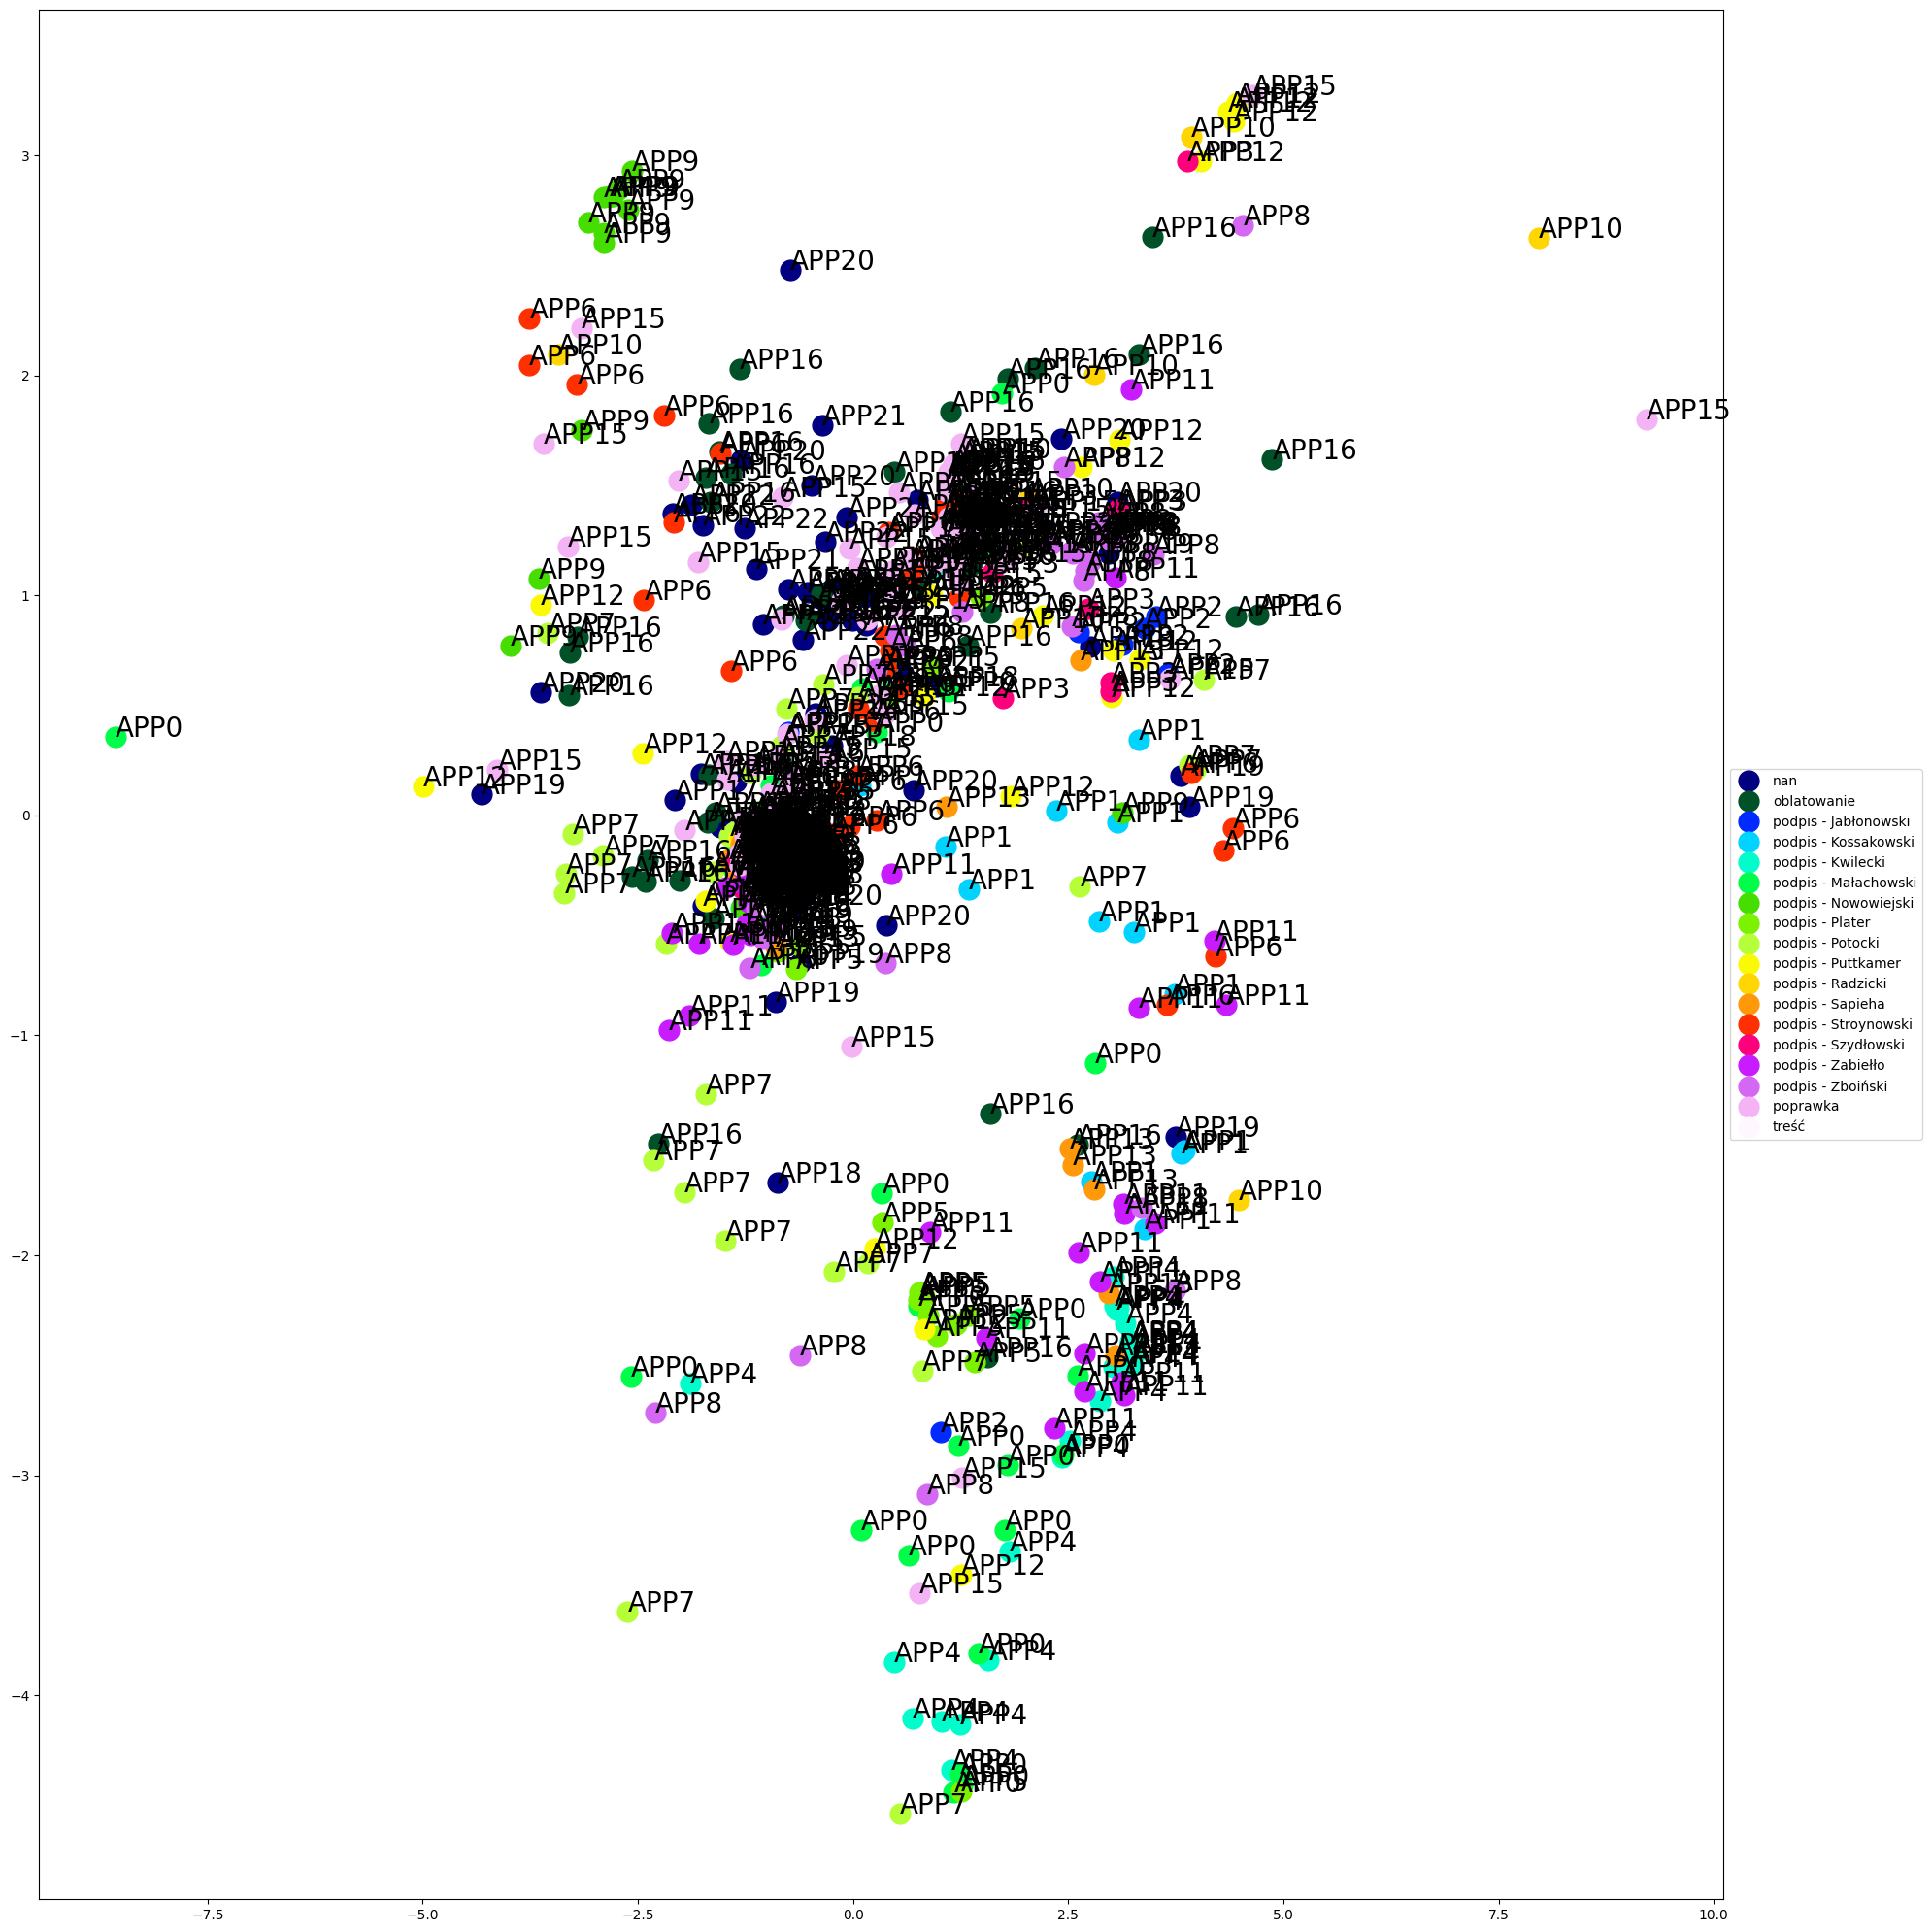

In [20]:
# if collapse:
#     color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
# else:
color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr], markersize=15)
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        ann = y[i].split(' - ')[-1][:3]
        ann = annotation[i]
        plt.annotate(ann, (X_pca[i, 0], X_pca[i,1]), size=20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gcf().set_size_inches((20,20))
plt.tight_layout()
#plt.savefig(figures_path[object_name]+'pca_' + book_name + '.png')

### tSNE

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

In [22]:
%matplotlib widget

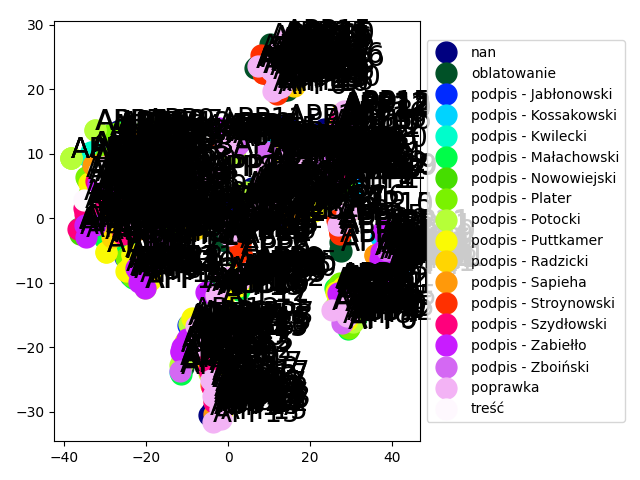

In [23]:
# if collapse:
#     color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
# else:
color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr], markersize=15)
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        ann = y[i].split(' - ')[-1][:3]
        ann = annotation[i]
        plt.annotate(ann, (X_tsne[i, 0], X_tsne[i,1]), fontsize=20)
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#plt.gcf().set_size_inches((20,20))
plt.tight_layout()
#plt.savefig(figures_path[object_name]+'tsne_annotation_' + book_name + '.png')

- drawing random records from the same group?

In [ ]:
########################################################

## Clustering

In [23]:
from sklearn import cluster

In [24]:
if collapse:
    y = [class_df['Class name'].iloc[13*i] for i in range(int(X.shape[0]))]
    y = [str(y) for y in y]
else:
    y = class_df['Class name']
    y = [str(y) for y in y]

In [25]:
cluster_only_names = False
if cluster_only_names:
    X_to_cluster = X[names_indices,:]
    y_to_plot = [y[ind] for ind in names_indices]
else:
    X_to_cluster = X
    y_to_plot = y

In [26]:
nr_of_clusters = 20
clustering = cluster.AgglomerativeClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.SpectralClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.DBSCAN().fit(X_to_cluster)

#clustering.labels_

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_to_cluster)

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_to_cluster)

In [28]:
#%matplotlib notebook

In [29]:
clustering.labels_.shape

(689,)

In [30]:
class_df['Code']

0          APP0
1          APP0
2          APP0
3          APP0
4          APP0
         ...   
684    ASCBLANK
685    ASCBLANK
686    ASCBLANK
687    ASCBLANK
688    ASCBLANK
Name: Code, Length: 689, dtype: object

In [31]:
set(y_to_plot)

{'Jabłonowski - podpis',
 'Kossakowski - podpis',
 'Kwilecki - podpis',
 'Małachowski - podpis',
 'Nowowiejski - podpis',
 'Plater - podpis',
 'Potocki - podpis',
 'Puttkamer - podpis',
 'Radzicki - podpis',
 'Sapieha - podpis',
 'Stroynowski - podpis',
 'Szydłowski - podpis',
 'Zabiełło - podpis',
 'Zboiński - podpis',
 'komentarz',
 'nan',
 'oblatowanie',
 'papier',
 'poprawka',
 'treść'}

In [32]:
list(reversed(sorted(set(y_to_plot))))

['treść',
 'poprawka',
 'papier',
 'oblatowanie',
 'nan',
 'komentarz',
 'Zboiński - podpis',
 'Zabiełło - podpis',
 'Szydłowski - podpis',
 'Stroynowski - podpis',
 'Sapieha - podpis',
 'Radzicki - podpis',
 'Puttkamer - podpis',
 'Potocki - podpis',
 'Plater - podpis',
 'Nowowiejski - podpis',
 'Małachowski - podpis',
 'Kwilecki - podpis',
 'Kossakowski - podpis',
 'Jabłonowski - podpis']

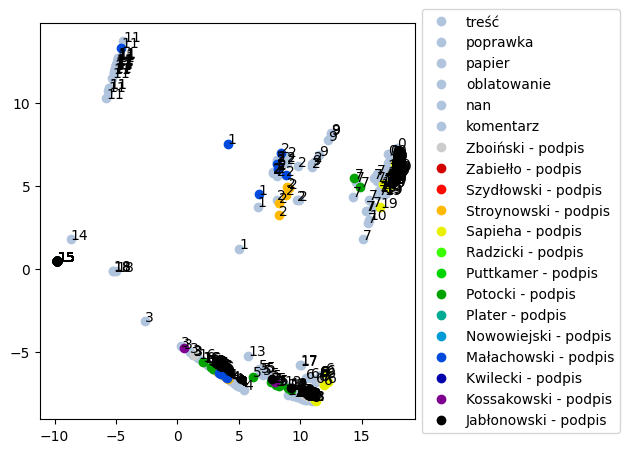

<Figure size 1000x700 with 0 Axes>

In [33]:
annotate = True

unidentified = ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']
names_set = set(y_to_plot).difference(set(unidentified))


if collapse:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
else:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
    
for label_nr, label in enumerate(reversed(sorted(set(y_to_plot)))):
    if label in unidentified:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color='lightsteelblue')
    else:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color=color[label_nr-len(unidentified)])
    
if annotate:
    for i in range(X_pca.shape[0]):
        if isinstance(y_to_plot[i], float):
            pass
        else:
            #version with cluster numbers
            plt.annotate(clustering.labels_[i], (X_pca[i, 0], X_pca[i,1]))
            #version with book name
            #plt.annotate(class_df['Code'][i], (X_pca[i, 0], X_pca[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.tight_layout()
plt.show()

plt.savefig('../figures/clustering_PCA_book_' + str(book_name) + '_annotate_' + str(annotate))

#PREDICTION ALL 13

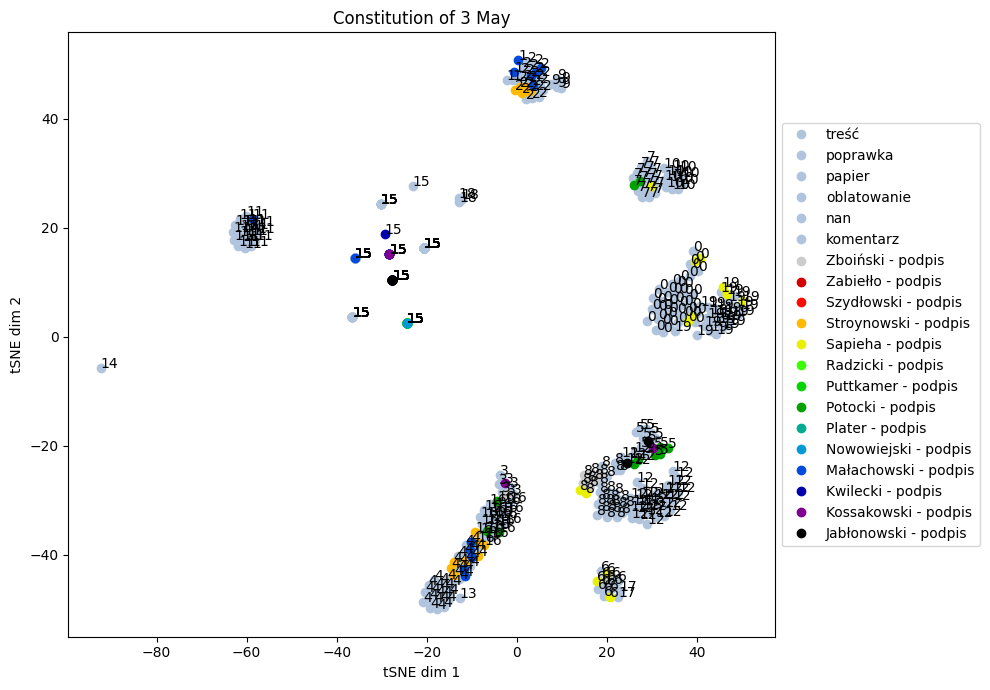

In [34]:
annotate = True

unidentified = ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']
names_set = set(y_to_plot).difference(set(unidentified))

if collapse:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
else:
    color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
    
for label_nr, label in enumerate(reversed(sorted(set(y_to_plot)))):
    if label in unidentified:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color='lightsteelblue')
#     elif label in ['nan']:
#         pass
    else:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color=color[label_nr-len(unidentified)])
    
if annotate:
    for i in range(X_tsne.shape[0]):
        if isinstance(y_to_plot[i], float):
            pass
        else:
            plt.annotate(clustering.labels_[i], (X_tsne[i, 0], X_tsne[i,1]))
            
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.xlabel('tSNE dim 1')
plt.ylabel('tSNE dim 2')
plt.title('Constitution of 3 May')

plt.tight_layout()
plt.show()

#plt.savefig('../figures/clustering_tSNE_book_' + str(book_name) + '_annotate_' + str(annotate))

#PREDICTION ALL 13

In [40]:
clusters = []
for i in range(nr_of_clusters):
    clust = [(int(el1), el2) for el1, el2 in list(zip(clustering.labels_, y_to_plot)) if el1==i]
    clusters.append(clust)

In [41]:
clusters

[[(0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'treść'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'komentarz'),
  (0, 'poprawka'),
  (0, 'poprawka'),
  (0, 'Sapieha - podpis'),
  (0, 'Sapieha - podpis'),
  (0, 'Sapieha - podpis'),
  (0, 'Sapieha - podpis'),
  (0, 'nan'),
  (0, 'papier'),
  (0, 'papier'),
  (0, 'papier'),
  (0, 'papier'),
  (0, 'papier'),
  (0, 'papier'),
  (0, 'papier'),
  (0, 'papier'),
  (0, 'papier')],
 [(1, 'poprawka'),
  (1, 'nan'),
  (1, 'Małachowski - podpis'),
  (1, 'Małachowski - podpi

In [45]:
with open(results_path[object_name] + 'clustering_of_predicted_inks_nr_of_clusters' + str(nr_of_clusters) + '.pkl', 'wb') as f:
    pickle.dump(clusters, f)

In [73]:
# EUCLIDEAN
# bad: 0, 2, 7, 8
# medium: 3, 6, 9, 10, 11
# good: 1, 4, 5, 12

# COSINE
# bad: 1, 4, 5, 6, 7
# medium: 3
# good: 0, 2

clusters

[[(0, 'poprawka'),
  (0, 'poprawka'),
  (0, 'treść'),
  (0, 'treść'),
  (0, 'poprawka'),
  (0, 'poprawka'),
  (0, 'poprawka')],
 [(1, 'nan'),
  (1, 'treść'),
  (1, 'treść'),
  (1, 'treść'),
  (1, 'poprawka'),
  (1, 'poprawka'),
  (1, 'poprawka'),
  (1, 'poprawka')],
 [(2, 'Radzicki'), (2, 'nan'), (2, 'treść'), (2, 'poprawka')],
 [(3, 'Nowowiejski'), (3, 'poprawka'), (3, 'poprawka'), (3, 'poprawka')],
 [(4, 'poprawka'), (4, 'poprawka')],
 [(5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka'),
  (5, 'poprawka')],
 [(6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść'),
  (6, 'treść')],
 [(7, 'Nowowiejski'), (7, 'nan')],
 [(8, 'treść'), (8, 'treść'), (8, 'treść')],
 [(9, 'treść'), (9, 'treść'), (9, 'treść')],
 [(10, 'treść'), (10, 'treść')],
 [(11, 'poprawka')],
 [(12, 'poprawka'),
  (12, 'poprawka'),
  (12, 'nan'),
  (12, 'nan'),
  (12, 'treść'),
  (12, 'treść'),
  (12, 'komen

In [ ]:
ms = cluster.MeanShift(banwidth=banwidth, bin_seeding=True)
two_means = cluster.MiniBatchKMeans(
    n_clusters=params["n_clusters"],
    random_state=params["random_state"],
)
ward = cluster.AgglomerativeClustering(
    n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
)
spectral = cluster.SpectralClustering(
    n_clusters=params["n_clusters"],
    eigen_solver="arpack",
    affinity="nearest_neighbors",
    random_state=params["random_state"],
)
dbscan = cluster.DBSCAN(eps=params["eps"])
hdbscan = cluster.HDBSCAN(
    min_samples=params["hdbscan_min_samples"],
    min_cluster_size=params["hdbscan_min_cluster_size"],
    allow_single_cluster=params["allow_single_cluster"],
)
optics = cluster.OPTICS(
    min_samples=params["min_samples"],
    xi=params["xi"],
    min_cluster_size=params["min_cluster_size"],
)
affinity_propagation = cluster.AffinityPropagation(
    damping=params["damping"],
    preference=params["preference"],
    random_state=params["random_state"],
)
average_linkage = cluster.AgglomerativeClustering(
    linkage="average",
    metric="cityblock",
    n_clusters=params["n_clusters"],
    connectivity=connectivity,
)
birch = cluster.Birch(n_clusters=params["n_clusters"])
gmm = mixture.GaussianMixture(
    n_components=params["n_clusters"],
    covariance_type="full",
    random_state=params["random_state"],
)

clustering_algorithms = (
    ("MiniBatch\nKMeans", two_means),
    ("Affinity\nPropagation", affinity_propagation),
    ("MeanShift", ms),
    ("Spectral\nClustering", spectral),
    ("Ward", ward),
    ("Agglomerative\nClustering", average_linkage),
    ("DBSCAN", dbscan),
    ("HDBSCAN", hdbscan),
    ("OPTICS", optics),
    ("BIRCH", birch),
    ("Gaussian\nMixture", gmm),
)